In [1]:
# --! include root folders into PYTHONPATH

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

# --! import Python libraries

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

# --! import framework libraries

import example_mujoco
import util_data
import util_nn

data_path = '../../../data/mujoco'
model_path = '../../../models/mujoco'
result_path = '../../../results/mujoco'

### Creating baseline dataset

In [2]:
data_nsample = 918
data = util_data.read_datafile(f'{data_path}/walker2d_baseline_0', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 17
act_ndim = 6
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

read data shape: torch.Size([80, 918, 23])
read observations shape: torch.Size([80, 918, 17])
read actions shape: torch.Size([80, 918, 6])
shape of observations for training: torch.Size([80, 917, 17])
shape of next observations for training: torch.Size([80, 917, 17])
shape of actions for training: torch.Size([80, 917, 6])


### Training mixture of experts

In [3]:
model = example_mujoco.model_moe(obs_ndim, act_ndim, nexpert=4)
model.train()
example_mujoco.train_moe(model, dataloader, nepoch=500)

epoch 0, loss: 0.064219
epoch 20, loss: 0.020982
epoch 40, loss: 0.009224
epoch 60, loss: 0.003307
epoch 80, loss: -0.000023
epoch 100, loss: -0.002030
epoch 120, loss: -0.003478
epoch 140, loss: -0.004477
epoch 160, loss: -0.005284
epoch 180, loss: -0.005802
epoch 200, loss: -0.006425
epoch 220, loss: -0.006857
epoch 240, loss: -0.007250
epoch 260, loss: -0.007555
epoch 280, loss: -0.007834
epoch 300, loss: -0.007926
epoch 320, loss: -0.008319
epoch 340, loss: -0.008538
epoch 360, loss: -0.008365
epoch 380, loss: -0.008830
epoch 400, loss: -0.009033
epoch 420, loss: -0.008640
epoch 440, loss: -0.009262
epoch 460, loss: -0.009410
epoch 480, loss: -0.009519


# Evaluating mixture of experts baseline

In [4]:
eval_data = util_data.read_datafile(f'{data_path}/walker2d_eval_0', data_nsample)
print(f'read evaluation data shape: {eval_data.shape}')

eval_obs, eval_act = torch.split(eval_data, [obs_ndim, act_ndim], dim=-1)
print(f'read evaluation observations shape: {eval_obs.shape}')
print(f'read evaluation actions shape: {eval_act.shape}')

# --! normalize evaluation data
eval_obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

read evaluation data shape: torch.Size([30, 918, 23])
read evaluation observations shape: torch.Size([30, 918, 17])
read evaluation actions shape: torch.Size([30, 918, 6])


In [11]:
model.eval()
util_nn.freeze_module(model)

reanchor_nsample = 1_000
this_traj = 4

s0 = eval_obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_moe(model, s0, eval_obs[this_traj], eval_act[this_traj], reanchor_nsample=reanchor_nsample)
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 17])


### Plotting rollout results

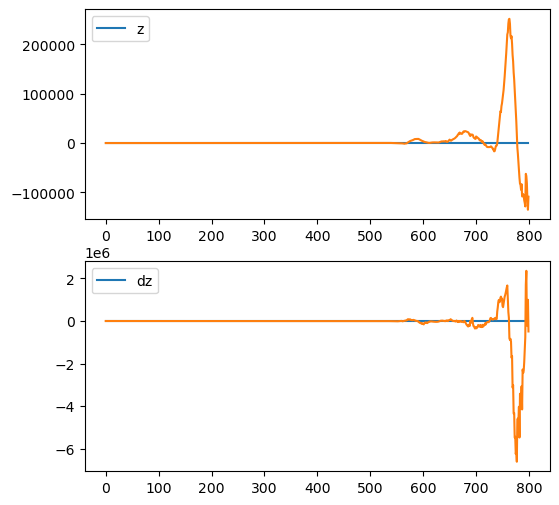

In [12]:
disp_end = 800
datasaved = False

plot_obs, plot_rollout = example_mujoco.disp_rollout(eval_obs, rollout_traj, obs_mean, obs_std, this_traj, disp_end)

if datasaved:
    save_step = torch.arange(eval_obs.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :disp_end, :1],
        plot_obs[:1, :disp_end, :1], plot_obs[:1, :disp_end, [9]],
        plot_rollout[:1, :disp_end, :1], plot_rollout[:1, :disp_end, [9]]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_moe_rollout', savedata, delim=' ')

In [7]:
traj_mse = []
with torch.no_grad():
    for j in range(eval_obs.shape[0]): # trajectory
        print(f'processing trajectory {j+1} out of {eval_obs.shape[0]}')
        mse = []
        for h in range(1, eval_obs.shape[1]): # horizon
            s0 = eval_obs[j, 0]
            cmp_rollout = example_mujoco.rollout_moe(
                model, s0,
                eval_obs[j, :h], eval_act[j, :h], reanchor_nsample=reanchor_nsample)

            # --! denormalize results
            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(eval_obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)

            # --! compute error
            loss = F.mse_loss(cmp_rollout, cmp_obs)
            mse.append(loss)
            if h % 100 == 0:
                print(f'\thorizon {h} out of {obs.shape[1]}, loss: {loss}')
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)


processing trajectory 1 out of 30
	horizon 100 out of 918, loss: 0.8780152797698975
	horizon 200 out of 918, loss: 2.67682147026062
	horizon 300 out of 918, loss: 4.3848114013671875
	horizon 400 out of 918, loss: 5.358267784118652
	horizon 500 out of 918, loss: 5.508787155151367
	horizon 600 out of 918, loss: 6.161099910736084
	horizon 700 out of 918, loss: 372.35882568359375
	horizon 800 out of 918, loss: 8803.740234375
	horizon 900 out of 918, loss: 18263094.0
processing trajectory 2 out of 30
	horizon 100 out of 918, loss: 2.617265462875366
	horizon 200 out of 918, loss: 3.5104987621307373
	horizon 300 out of 918, loss: 4.9513020515441895
	horizon 400 out of 918, loss: 4.994431972503662
	horizon 500 out of 918, loss: 4.265003204345703
	horizon 600 out of 918, loss: 3.6763455867767334
	horizon 700 out of 918, loss: 3.89677357673645
	horizon 800 out of 918, loss: 4.22873592376709
	horizon 900 out of 918, loss: 4.582357406616211
processing trajectory 3 out of 30
	horizon 100 out of 918

tensor(0.1028)
tensor(0.1027)


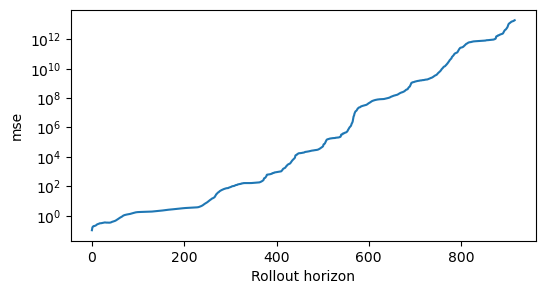

In [8]:
traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.xlabel('Rollout horizon')
    plt.ylabel('mse')
    plt.show()

datasaved = False
if datasaved:
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_moe_mse', savedata, delim=' ')